# 基于决策树&随机森林的鲍鱼年龄预测

## 1、 加载鲍鱼数据集

In [1]:
# 环境配置：中文字体显示
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
import numpy as np
import pandas as pd
from IPython.display import display

# 方法1、在线加载鲍鱼数据集文件（csv格式，建议复制链接下载到本地，然后使用方法2加载）
# url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data'
# data = pd.read_csv(url) # 读取在线数据

# 方法2、加载本地数据文件（abalone.data文件）
abalone = pd.read_csv('abalone.data', header=None)

# 原数据中没有表头（即特征名称），我们加上便于观察数据
abalone.columns = ['Sex', 'Length', 'Diameter', 'Height',
                'Whole weight', 'Shucked weight', 'Viscera weight',
                'Shell weight', 'Rings']

display(abalone) # 展示4176条数据，8个特征（最后一列Rings代表环数，即年龄，相当于数据的标签）


,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [3]:
# 性别特征的值是M、F和I（未知），为了便于算法计算，需要变成数字
new_abalone = abalone.replace({'Sex': {'M': 0, 'F': 1, 'I': 2}}) # M、F、I分别替换为0,1,2
display(new_abalone)


,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,0,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,1,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,0,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,2,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,1,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,0,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,0,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,1,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


## 2、拆分数据集

In [4]:
from sklearn.model_selection import train_test_split

# 从数据集中分离样本数据和标签数据
data = new_abalone.iloc[:, :8] # 前8列（特征数据）
target = new_abalone.iloc[:, 8] # 最后一列（年龄）

# 拆分数据集
X_train, X_test, y_train, y_test = train_test_split(data, target, random_state=0)

print(X_train.shape, X_test.shape) # 查看拆分结果


(3132, 8) (1045, 8)


## 3、构建回归模型

In [5]:
from sklearn.tree import DecisionTreeRegressor # 导入决策树模型
# from sklearn.ensemble import RandomForestRegressor # 导入随机森林
# from sklearn.linear_model import LinearRegression # 线性回归模型


# 创建回归模型并训练
model = DecisionTreeRegressor(random_state=0).fit(X_train, y_train) # 决策树（默认参数）
#model = RandomForestRegressor(50).fit(X_train, y_train) # 使用50棵决策树构成随机森林
#model = LinearRegression().fit(X_train, y_train) # 线性回归

# 评估模型（分类模型输出准确率，回归模型输出R2_score）
print('test_score:', model.score(X_test, y_test))

# 预测测试集中的鲍鱼年龄
y_pred = model.predict(X_test)
n = 10 # 显示前n个样本的预测年龄，并与实际年龄作对比
print('预测年龄：', np.round(y_pred[:n])) # np.round()-四舍五入取整
print('实际年龄：', y_test.values[:n])


test_score: 0.14487775452534923
预测年龄： [10. 11. 11.  4. 11. 10. 10.  7.  9. 12.]
实际年龄： [13  8 11  5 12 11  7  8  7  9]


## 4、可视化预测曲线

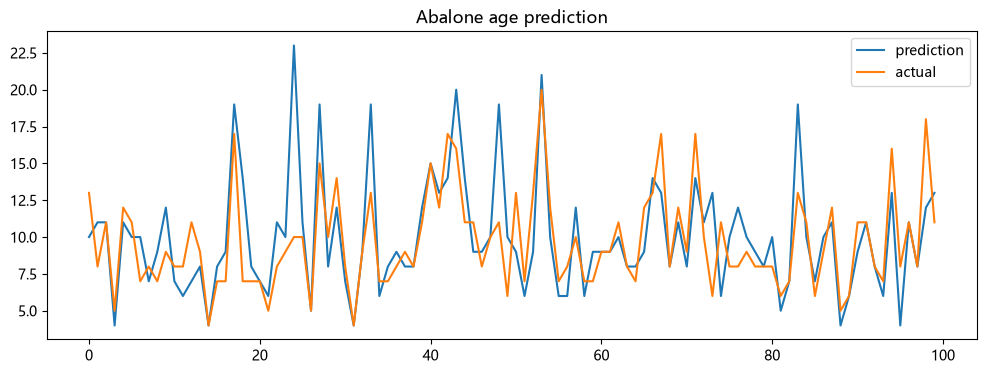

In [6]:
import matplotlib.pyplot as plt

# 可视化预测曲线
plt.figure(figsize=(12,4)) # 图像尺寸(12,4)
plt.title('Abalone age prediction') # 标题
n = 100 # 图中显示样本的数量
plt.plot(y_pred[:n], label='prediction') # 预测值
plt.plot(y_test.values[:n], label='actual') # 实际值
plt.legend() # 显示图例
plt.show()


## 5、决策树及集成算法实现肿瘤分类预测
+ 决策树及集成算法(随机森林、AdaBoost)既可以解决回归问题，也可以解决分类问题。
+ 本任务中，我们对比上述模型在肿瘤分类预测案例中的表现。

In [7]:
from sklearn.tree import DecisionTreeClassifier # 导入决策树模块
from sklearn.ensemble import RandomForestClassifier # 导入随机森林模块
from sklearn.ensemble import AdaBoostClassifier # 导入AdaBoost模块
from sklearn.datasets import load_breast_cancer # 导入肿瘤数据集
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer() # 加载cancer数据集

# 拆分数据集
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)
# 创建多种分类模型并训练
m_1 = DecisionTreeClassifier(random_state=0).fit(X_train, y_train) # 无参数决策树（过拟合现象严重）
m_2 = DecisionTreeClassifier(max_depth=4, random_state=0).fit(X_train, y_train) # 指定剪枝参数
m_3 = RandomForestClassifier(n_estimators=50, random_state=0).fit(X_train, y_train) # 随机森林（使用50棵决策树）
m_4 = AdaBoostClassifier(random_state=0).fit(X_train, y_train) # AdaBoost

# 评估模型，对比准确率
models = {'d_tree_1':m_1, 'd_tree_2':m_2, 'r_forest':m_3, 'adaboost':m_4}
for m in models:
    score_train = models[m].score(X_train, y_train)
    score_test = models[m].score(X_test, y_test)
    print('{}: train_score {:.2f}  test_score {:.2f}'.format(m, score_train, score_test))


d_tree_1: train_score 1.00  test_score 0.88
d_tree_2: train_score 0.99  test_score 0.90
r_forest: train_score 1.00  test_score 0.97
adaboost: train_score 1.00  test_score 0.94
